In [55]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import networkx as nx

In [36]:
# load data
file_path = "data/dataset.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Successfully loaded dataset with {df.shape[0]} patient records.")
    
    print(df.head())
else:
    print("Error: dataset.csv not found.")

Successfully loaded dataset with 4920 patient records.
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic _patches       NaN       NaN       NaN       NaN       NaN   
1                   NaN       NaN       NaN       NaN       NaN       NaN   
2                   NaN       NaN       NaN       NaN       NaN       NaN   
3                   NaN       NaN       NaN       NaN       NaN       NaN   
4                   NaN       NaN       NaN       NaN       NaN       NaN

In [37]:
# preprocess data
symptoms_list = df.iloc[:, 1:].apply(
    lambda row: [str(val).strip() for val in row if pd.notna(val)], 
    axis=1
)

# convert lists into a binary 1/0 matrix
mlb = MultiLabelBinarizer()
binary_matrix = mlb.fit_transform(symptoms_list)

# create new and clean dataframe
clean_df = pd.DataFrame(binary_matrix, columns=mlb.classes_)

# put the disease to the front
clean_df.insert(0, 'Disease', df['Disease'])

print(f"Old shape (with NaNs): {df.shape}")
print(f"New shape (Binary Matrix): {clean_df.shape}")
print("\nCleaned Data Preview:")
clean_df.head()

Old shape (with NaNs): (4920, 18)
New shape (Binary Matrix): (4920, 132)

Cleaned Data Preview:


,Disease,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
# split data into training and testing sets

X = clean_df.drop(columns=['Disease']) # all symptoms
y = clean_df['Disease'] # disease

# 20% of whole dataset split to test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_data = pd.concat([y_train, X_train], axis=1)
test_data = pd.concat([y_test, X_test], axis=1)

print(f"Total Patient Records: {clean_df.shape[0]}")
print(f"Training Set Size: {train_data.shape[0]}")
print(f"Testing Set Size: {test_data.shape[0]}")
train_data.head()

Total Patient Records: 4920
Training Set Size: 3936
Testing Set Size: 984


,Disease,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
3374,Cervical spondylosis,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1432,Hepatitis B,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
3663,Jaundice,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
3296,Chicken pox,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3232,Osteoarthristis,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
print("Conditional Independence Tests on specific symptom pairs\n")

def test_independence(df, col1, col2):
    contingency_table = pd.crosstab(df[col1], df[col2])
    
    # 2. Run the Chi-Square Test
    # chi2: The test statistic
    # p: The p-value (The probability this correlation is random chance)
    # dof: Degrees of freedom
    # expected: The expected frequencies if they were independent
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    return p

# TEST 1: Check dependency between two related symptoms (e.g., Nausea and Vomiting)
symptom_A = 'nausea'
symptom_B = 'vomiting'

if symptom_A in clean_df.columns and symptom_B in clean_df.columns:
    p_value = test_independence(clean_df, symptom_A, symptom_B)
    
    print(f"Test 1: Are '{symptom_A}' and '{symptom_B}' independent?")
    print(f"  - P-value: {p_value}")
    if p_value < 0.05:
        print("  - Result: REJECT Null Hypothesis -> They are DEPENDENT (correlated).")
    else:
        print("  - Result: ACCEPT Null Hypothesis -> They are INDEPENDENT.")
else:
    print(f"Skipping Test 1: Columns '{symptom_A}' or '{symptom_B}' not found.")

print("-" * 50)

# TEST 2: Check dependency between unrelated/weakly related symptoms
symptom_C = 'knee_pain'
symptom_D = 'watering_from_eyes'

if symptom_C in clean_df.columns and symptom_D in clean_df.columns:
    p_value_2 = test_independence(clean_df, symptom_C, symptom_D)

    print(f"Test 2: Are '{symptom_C}' and '{symptom_D}' independent?")
    print(f"  - P-value: {p_value_2}")
    if p_value_2 < 0.05:
        print("  - Result: REJECT Null Hypothesis -> They are DEPENDENT.")
    else:
        print("  - Result: ACCEPT Null Hypothesis -> They are INDEPENDENT.")
else:
    print(f"Skipping Test 2: Columns '{symptom_C}' or '{symptom_D}' not found.")

Conditional Independence Tests on specific symptom pairs

Test 1: Are 'nausea' and 'vomiting' independent?
  - P-value: 3.5559269785243994e-296
  - Result: REJECT Null Hypothesis -> They are DEPENDENT (correlated).
--------------------------------------------------
Test 2: Are 'knee_pain' and 'watering_from_eyes' independent?
  - P-value: 0.19530151859525097
  - Result: ACCEPT Null Hypothesis -> They are INDEPENDENT.


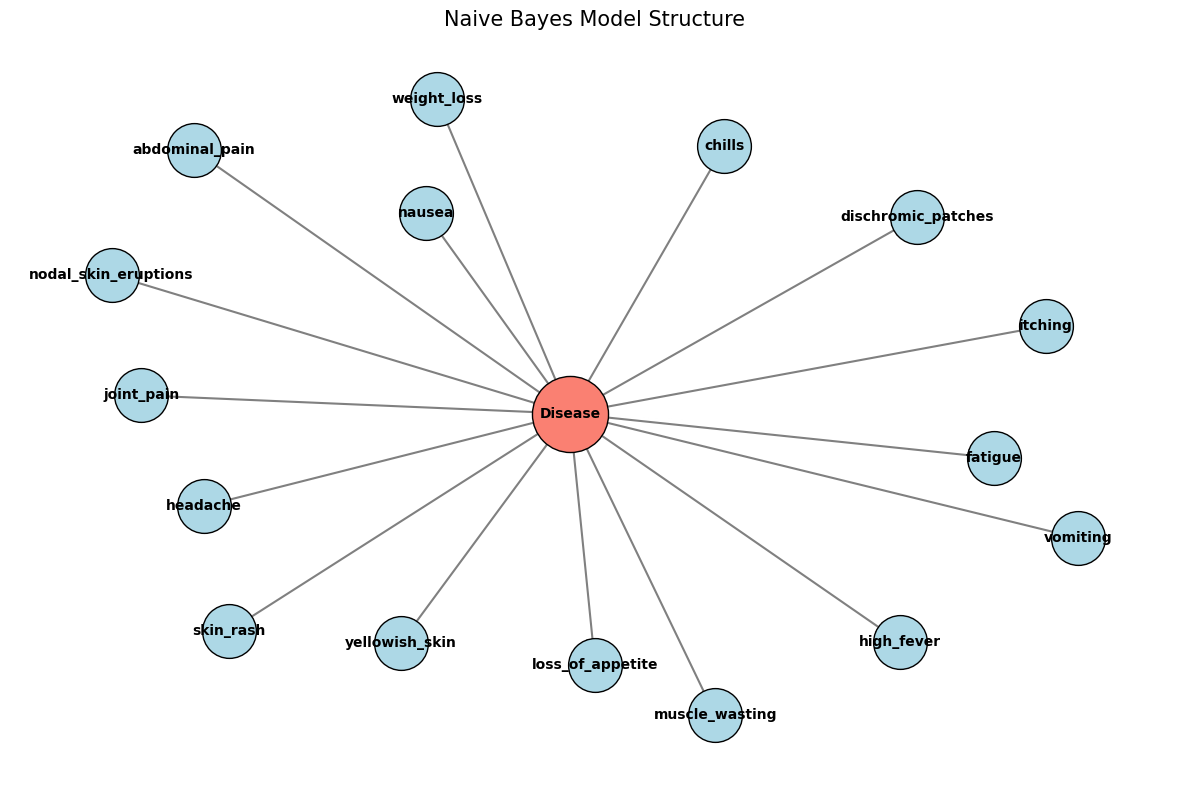

In [40]:
parent = "Disease"
symptoms = [
    "itching", "skin_rash", "nodal_skin_eruptions", "dischromic_patches",
    "abdominal_pain", "vomiting", "yellowish_skin", "nausea",
    "loss_of_appetite", "high_fever", "headache", "chills",
    "joint_pain", "muscle_wasting", "fatigue", "weight_loss"
]

# symptoms = [col for col in clean_df.columns if col != 'Disease']

G = nx.DiGraph()

edges = [(parent, symptom) for symptom in symptoms]
G.add_edges_from(edges)

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

pos[parent] = [0, 0] 

nx.draw_networkx_nodes(G, pos, nodelist=[parent], node_color='salmon', node_size=3000, edgecolors='black')

nx.draw_networkx_nodes(G, pos, nodelist=symptoms, node_color='lightblue', node_size=1500, edgecolors='black')

nx.draw_networkx_edges(G, pos, edgelist=edges, arrows=True, arrowstyle='->', arrowsize=20, width=1.5, edge_color='gray')

nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("Naive Bayes Model Structure", fontsize=15)
plt.axis('off')
plt.tight_layout()

plt.savefig("naive_bayes_structure.png", format="png", dpi=300)
plt.show()

In [41]:
symptoms = [col for col in clean_df.columns if col != 'Disease'] # actual dag
parent = "Disease"

G = nx.DiGraph()

edges = [(parent, symptom) for symptom in symptoms]
G.add_edges_from(edges)


# === VISUALIZE DAG ===
# plt.figure(figsize=(12, 8))
# pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)
# pos[parent] = [0, 0] 
# nx.draw_networkx_nodes(G, pos, nodelist=[parent], node_color='salmon', node_size=3000, edgecolors='black')
# nx.draw_networkx_nodes(G, pos, nodelist=symptoms, node_color='lightblue', node_size=1500, edgecolors='black')
# nx.draw_networkx_edges(G, pos, edgelist=edges, arrows=True, arrowstyle='->', arrowsize=20, width=1.5, edge_color='gray')
# nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
# plt.title("Naive Bayes Model Structure", fontsize=15)
# plt.axis('off')
# plt.tight_layout()
# plt.savefig("naive_bayes_structure.png", format="png", dpi=300)
# plt.show()

In [42]:
# Compute priors
disease_counts = train_data['Disease'].value_counts()
prior = disease_counts / len(train_data)


# Compute CPTs: P(Symptom=1 | Disease) for all symptom-disease pairs
# mean of a binary column grouped by disease = MLE estimate of P(symptom=1 | disease) = (count of symptom == 1)/average
# cpt = train_data.groupby('Disease')[symptoms].mean()

alpha = 1.0  # Laplace smoothing strength
grouped = train_data.groupby("Disease")[symptoms]
count_ones = grouped.sum()
count_total = grouped.count()
cpt = (count_ones + alpha) / (count_total + 2*alpha)

# Show CPT for first 3 diseases
example_cpt = cpt.loc[cpt.index[:3]]
nonzero_symptoms = example_cpt.columns[example_cpt.sum() > 0] # only show non-zero cols
example_cpt[nonzero_symptoms].head()

,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
Disease,,,,,,,,,,,,,,,,,,,,,
(vertigo) Paroymsal Positional Vertigo,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,...,0.948980,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204
AIDS,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,...,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204
Acne,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.897959,0.010204,...,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204,0.010204


In [43]:
# Inference on Test Set

# prior P(Disease)
# posterior P(Disease | Symptom)
# likelihood P(Symptom | Disease)
# evidence P(Symptom)

def predict_disease(patient_row, priors, cpt):
    posteriors = {}

    for disease in priors.index:
        prob = priors[disease]
        for symptom in cpt.columns:
            likelihood = cpt.loc[disease, symptom]
            if patient_row[symptom] == 1:
                prob *= likelihood
            else:
                prob = (1 - likelihood) * prob

        posteriors[disease] = prob

    # divide each by P(Symptom) = sum(P(Symptoms | D)P(D))
    evidence = sum(posteriors.values())
    if evidence == 0:
    # fallback: return most common prior
        best = priors.idxmax()
        return best, priors[best]
    
    for posterior in posteriors:
        posteriors[posterior] /= evidence

    # prediction
    best_pred = None
    best_prob = -1
    for posterior in posteriors:
        if posteriors[posterior] > best_prob:
            best_prob = posteriors[posterior]
            best_pred = posterior
            
    return best_pred, best_prob


In [48]:
examples = []
predictions = []
correct = 0
total = len(test_data)
for i, row in test_data.iterrows():
    true_label = row["Disease"]
    patient_symptoms = row.drop("Disease")
    pred_label, pred_prob = predict_disease(patient_symptoms, prior, cpt)
    predictions.append(pred_label)
    if pred_label == true_label:
        correct += 1

    # save some example cases
    if len(examples) < 5:
        examples.append({
            "index": i,
            "true": true_label,
            "pred": pred_label,
            "prob": pred_prob,
            "symptoms": patient_symptoms.to_dict()
        })

accuracy = correct / total

print("Accuracy:", accuracy)
print("\n--- Example Predictions ---")

for ex in examples:
    print(f"\nPatient {ex['index']}")
    print("True disease:", ex["true"])
    print("Predicted:", ex["pred"])
    print("Posterior probability:", round(ex["prob"], 4))


Accuracy: 1.0

--- Example Predictions ---

Patient 101
True disease: Hypertension 
Predicted: Hypertension 
Posterior probability: 1.0

Patient 3120
True disease: Drug Reaction
Predicted: Drug Reaction
Posterior probability: 1.0

Patient 694
True disease: Dimorphic hemmorhoids(piles)
Predicted: Dimorphic hemmorhoids(piles)
Posterior probability: 1.0

Patient 2374
True disease: Hyperthyroidism
Predicted: Hyperthyroidism
Posterior probability: 1.0

Patient 1163
True disease: Osteoarthristis
Predicted: Osteoarthristis
Posterior probability: 1.0


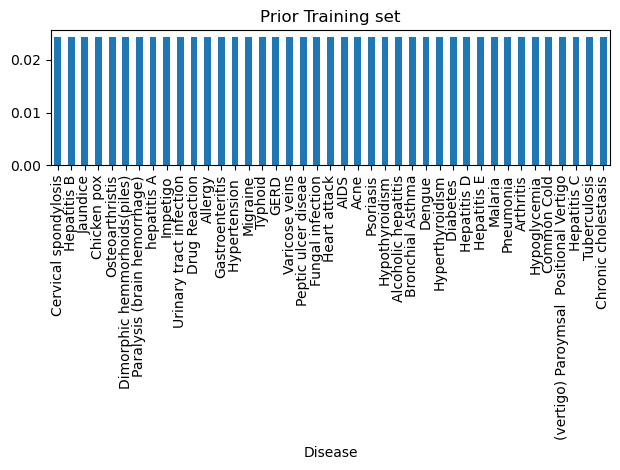

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00        24
                           

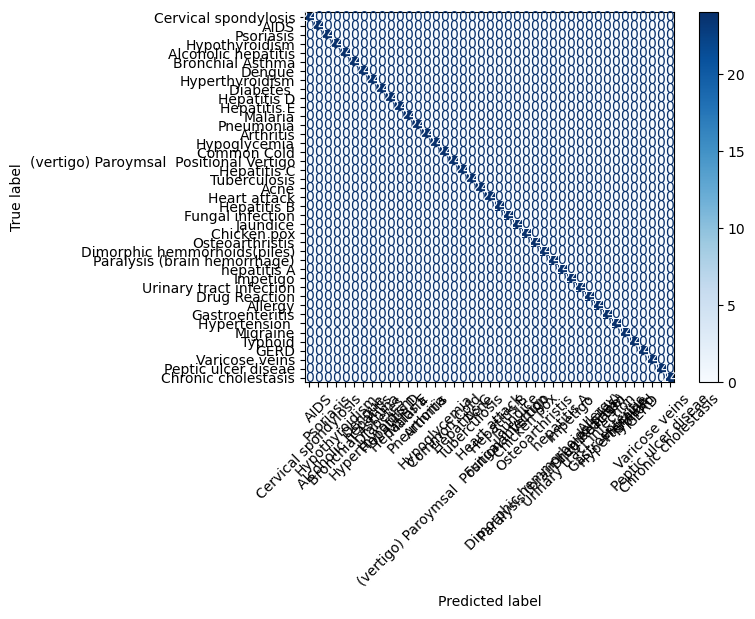

In [58]:
# bar graph visualization
prior.sort_values(ascending=False).plot(kind="bar", title="Prior Training set")
plt.tight_layout()
plt.show()

# display performance metrics and confusion matrix 
y_true = test_data["Disease"].to_numpy()
y_pred = np.array(predictions)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=prior.index)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=prior.index)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()